**Importing Necessery Library**

In [ ]:
from google.colab import drive
import pandas as pd
import os

**Data Loading and Preparation**

In [ ]:
drive.mount('/content/drive')

# Path to the folder containing the dataset
folder_path = '/content/drive/My Drive/ecom/'

# All CSV files in the ecom folder
csv_files = [file for file in os.listdir(folder_path) if file.endswith('.csv')]

# Loading all CSV file into a DataFrame and store in a dictionary
data = {}
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    data[file.split('.')[0]] = pd.read_csv(file_path)

# Displaying the first few rows of each DataFrame
for name, df in data.items():
    print(f"Dataset: {name}\n")
    print(df.head())
    print("\n")

Mounted at /content/drive


<ipython-input-2-97b26fe6252d>:13: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  data[file.split('.')[0]] = pd.read_csv(file_path)


Dataset: Expense IIGF

   index Recived Amount Unnamed: 1  \
0      0     Particular     Amount   
1      1       06-19-22       1000   
2      2       06-20-22       1500   
3      3       06-22-22        500   
4      4       06-23-22       2000   

                                             Expance Unnamed: 3  
0                                         Particular     Amount  
1                                          Large Bag        380  
2  Stationary(Soft Pin, Paper pin for Dupatta, Fe...        170  
3                                                OLA        839  
4                                          Auto Rent        520  


Dataset: Cloud Warehouse Compersion Chart

   index                        Shiprocket        Unnamed: 1  \
0      0                             Heads  Price (Per Unit)   
1      1     Inbound (Fresh Stock and RTO)             ₹4.00   
2      2                          Outbound             ₹7.00   
3      3                   Storage Fee/Cft         

Checking for duplicates

In [ ]:
for name, df in data.items():
    print(f"Dataset: {name}")
    print("Number of duplicate rows:", df.duplicated().sum())
    print("\n")

Dataset: Expense IIGF
Number of duplicate rows: 0


Dataset: Cloud Warehouse Compersion Chart
Number of duplicate rows: 0


Dataset: Sale Report
Number of duplicate rows: 0


Dataset: Amazon Sale Report
Number of duplicate rows: 0


Dataset: International sale Report
Number of duplicate rows: 0


Dataset: May-2022
Number of duplicate rows: 0


Dataset: P  L March 2021
Number of duplicate rows: 0




Checking Data Types

In [ ]:
# Displaying data types of all columns from dataset
for name, df in data.items():
    print(f"Dataset: {name}")
    print(df.dtypes)
    print("\n")


Dataset: Expense IIGF
index              int64
Recived Amount    object
Unnamed: 1        object
Expance           object
Unnamed: 3        object
dtype: object


Dataset: Cloud Warehouse Compersion Chart
index          int64
Shiprocket    object
Unnamed: 1    object
INCREFF       object
dtype: object


Dataset: Sale Report
index           int64
SKU Code       object
Design No.     object
Stock         float64
Category       object
Size           object
Color          object
dtype: object


Dataset: Amazon Sale Report
index                   int64
Order ID               object
Date                   object
Status                 object
Fulfilment             object
Sales Channel          object
ship-service-level     object
Style                  object
SKU Code               object
Category               object
Size                   object
ASIN                   object
Courier Status         object
Qty                     int64
currency               object
Amount                floa

Correcting Data Types

In [ ]:
# Converting columns to appropriate data types for each dataset
data['Expense IIGF']['Recived Amount'] = pd.to_numeric(data['Expense IIGF']['Recived Amount'], errors='coerce')
data['Cloud Warehouse Compersion Chart']['Shiprocket'] = pd.to_numeric(data['Cloud Warehouse Compersion Chart']['Shiprocket'], errors='coerce')
data['Cloud Warehouse Compersion Chart']['INCREFF'] = pd.to_numeric(data['Cloud Warehouse Compersion Chart']['INCREFF'], errors='coerce')
data['Sale Report']['Stock'] = pd.to_numeric(data['Sale Report']['Stock'], errors='coerce')
data['International sale Report']['PCS'] = pd.to_numeric(data['International sale Report']['PCS'], errors='coerce')
data['International sale Report']['RATE'] = pd.to_numeric(data['International sale Report']['RATE'], errors='coerce')
data['International sale Report']['GROSS AMT'] = pd.to_numeric(data['International sale Report']['GROSS AMT'], errors='coerce')
data['P  L March 2021'] = data['P  L March 2021'].apply(pd.to_numeric, errors='ignore')
data['May-2022'] = data['May-2022'].apply(pd.to_numeric, errors='ignore')
data['Amazon Sale Report']['Date'] = pd.to_datetime(data['Amazon Sale Report']['Date'], errors='coerce')

# Displaying data types of all columns after converting
for name, df in data.items():
    print(f"Dataset: {name}")
    print(df.dtypes)
    print("\n")


Dataset: Expense IIGF
index               int64
Recived Amount    float64
Unnamed: 1         object
Expance            object
Unnamed: 3         object
dtype: object


Dataset: Cloud Warehouse Compersion Chart
index           int64
Shiprocket    float64
Unnamed: 1     object
INCREFF       float64
dtype: object


Dataset: Sale Report
index           int64
SKU Code       object
Design No.     object
Stock         float64
Category       object
Size           object
Color          object
dtype: object


Dataset: Amazon Sale Report
index                          int64
Order ID                      object
Date                  datetime64[ns]
Status                        object
Fulfilment                    object
Sales Channel                 object
ship-service-level            object
Style                         object
SKU Code                      object
Category                      object
Size                          object
ASIN                          object
Courier Status         

Checking for missing values in each dataset

In [ ]:
for name, df in data.items():
    print(f"Dataset: {name}")
    print(df.isnull().sum())
    print("\n")


Dataset: Expense IIGF
index              0
Recived Amount    17
Unnamed: 1        11
Expance            2
Unnamed: 3         0
dtype: int64


Dataset: Cloud Warehouse Compersion Chart
index          0
Shiprocket    50
Unnamed: 1     9
INCREFF       47
dtype: int64


Dataset: Sale Report
index          0
SKU Code      83
Design No.    36
Stock         36
Category      45
Size          36
Color         45
dtype: int64


Dataset: Amazon Sale Report
index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU Code                  0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country      

Handling missing values

Handling missing values for Expense IIGF

In [ ]:
def handle_missing_values_expense_iigf(df):
    print("Handling missing values for dataset: Expense IIGF")
    print("Before handling missing values:")
    print(df.shape)
    print(df.columns)

    if df.shape[0] > 0:
        # Filling missing values with the most frequent value in each column
        df = df.fillna(df.mode().iloc[0])

        print("After handling missing values:")
        print(df.shape)
        print(df.columns)

    else:
        print("No data available in the dataset.")

    return df

# Applying the function to the Expense IIGF dataset
expense_iigf_processed = handle_missing_values_expense_iigf(data['Expense IIGF'])
print("Missing values handled for dataset: Expense IIGF\n")


Handling missing values for dataset: Expense IIGF
Before handling missing values:
(17, 5)
Index(['index', 'Recived Amount', 'Unnamed: 1', 'Expance', 'Unnamed: 3'], dtype='object')
After handling missing values:
(17, 5)
Index(['index', 'Recived Amount', 'Unnamed: 1', 'Expance', 'Unnamed: 3'], dtype='object')
Missing values handled for dataset: Expense IIGF



 Handling missing values for Cloud Warehouse Compersion Chart

In [ ]:
import pandas as pd
import numpy as np

def handle_missing_values_cloud_warehouse(df):
    print("Before handling missing values:")
    print(df.shape)
    print(df.columns)

    # Droping columns with all missing values
    df.dropna(axis=1, how='all', inplace=True)

    # Filling missing values in columns
    if 'Shiprocket' in df.columns:
        df['Shiprocket'].fillna(df['Shiprocket'].mean(), inplace=True)
    if 'INCREFF' in df.columns:
        df['INCREFF'].fillna(method='ffill', inplace=True)

    print("After handling missing values:")
    print(df.shape)
    print(df.columns)

    return df

# Example usage
cloud_warehouse_compersion_chart_processed = handle_missing_values_cloud_warehouse(data['Cloud Warehouse Compersion Chart'])
print("Missing values handled for dataset: Cloud Warehouse Compersion Chart")


Before handling missing values:
(50, 4)
Index(['index', 'Shiprocket', 'Unnamed: 1', 'INCREFF'], dtype='object')
After handling missing values:
(50, 3)
Index(['index', 'Unnamed: 1', 'INCREFF'], dtype='object')
Missing values handled for dataset: Cloud Warehouse Compersion Chart


Handling missing values for Sale Report


In [ ]:
import pandas as pd

# Function for handling missing values for Sale Report dataset

def handle_missing_values_sale_report(df):
    print(f"Before handling missing values for Sale Report:\n{df.shape}\n{df.columns}")

    # Dropping rows with any missing values
    df.dropna(inplace=True)

    print(f"After handling missing values for Sale Report:\n{df.shape}\n{df.columns}")

    return df

# Applying the function to the Sale Report dataset
print(f"Handling missing values for dataset: Sale Report")
sale_report_processed = handle_missing_values_sale_report(data['Sale Report'])
print(f"Missing values handled for dataset: Sale Report\n")


Handling missing values for dataset: Sale Report
Before handling missing values for Sale Report:
(9271, 7)
Index(['index', 'SKU Code', 'Design No.', 'Stock', 'Category', 'Size',
       'Color'],
      dtype='object')
After handling missing values for Sale Report:
(9188, 7)
Index(['index', 'SKU Code', 'Design No.', 'Stock', 'Category', 'Size',
       'Color'],
      dtype='object')
Missing values handled for dataset: Sale Report



Handling missing values for International sale Report


In [ ]:
import pandas as pd

# Function for handling missing values for International sale Report dataset
def handle_missing_values_international_sale_report(df):
    print(f"Before handling missing values for International sale Report:\n{df.shape}\n{df.columns}")

    # Dropping rows with any missing values
    df.dropna(inplace=True)

    print(f"After handling missing values for International sale Report:\n{df.shape}\n{df.columns}")

    return df

# Applying the function to the International sale Report dataset
print(f"Handling missing values for dataset: International sale Report")
international_sale_report_processed = handle_missing_values_international_sale_report(data['International sale Report'])
print(f"Missing values handled for dataset: International sale Report\n")


Handling missing values for dataset: International sale Report
Before handling missing values for International sale Report:
(37432, 10)
Index(['index', 'DATE', 'Months', 'CUSTOMER', 'Style', 'SKU Code', 'Size',
       'PCS', 'RATE', 'GROSS AMT'],
      dtype='object')
After handling missing values for International sale Report:
(34957, 10)
Index(['index', 'DATE', 'Months', 'CUSTOMER', 'Style', 'SKU Code', 'Size',
       'PCS', 'RATE', 'GROSS AMT'],
      dtype='object')
Missing values handled for dataset: International sale Report



 Handling missing values for Amazon Sale Report


In [ ]:
import pandas as pd

# Function for handling missing values for Amazon Sale Report dataset
def handle_missing_values_amazon_sale_report(df):
    print(f"Before handling missing values for Amazon Sale Report:\n{df.shape}\n{df.columns}")

    # Dropping rows with any missing values
    df.dropna(inplace=True)

    print(f"After handling missing values for Amazon Sale Report:\n{df.shape}\n{df.columns}")

    return df

# Applying the function to the Amazon Sale Report dataset
print(f"Handling missing values for dataset: Amazon Sale Report")
amazon_sale_report_processed = handle_missing_values_amazon_sale_report(data['Amazon Sale Report'])
print(f"Missing values handled for dataset: Amazon Sale Report\n")


Handling missing values for dataset: Amazon Sale Report
Before handling missing values for Amazon Sale Report:
(128975, 24)
Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU Code', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')
After handling missing values for Amazon Sale Report:
(19379, 24)
Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU Code', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')
Missing values handled for dataset: Amazon Sale Report



Checking Missing value Again

In [ ]:
for name, df in data.items():
    print(f"Dataset: {name}")
    print(df.isnull().sum())
    print("\n")


Dataset: Expense IIGF
index              0
Recived Amount    17
Unnamed: 1        11
Expance            2
Unnamed: 3         0
dtype: int64


Dataset: Cloud Warehouse Compersion Chart
index         0
Unnamed: 1    9
INCREFF       1
dtype: int64


Dataset: Sale Report
index         0
SKU Code      0
Design No.    0
Stock         0
Category      0
Size          0
Color         0
dtype: int64


Dataset: Amazon Sale Report
index                 0
Order ID              0
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
SKU Code              0
Category              0
Size                  0
ASIN                  0
Courier Status        0
Qty                   0
currency              0
Amount                0
ship-city             0
ship-state            0
ship-postal-code      0
ship-country          0
promotion-ids         0
B2B                   0
fulfilled-by          0
Unnamed: 22           0
d

**Exploratory Data Analysis (EDA)**

Sales Trends Analysis from Amazon Sale Report

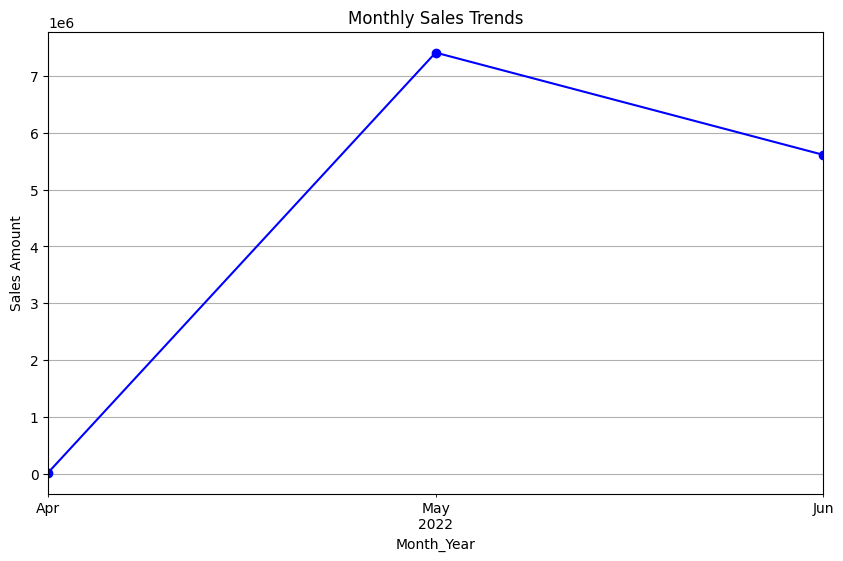

In [ ]:
import matplotlib.pyplot as plt

# Extracting month and year from the Date column
data['Amazon Sale Report']['Month_Year'] = pd.to_datetime(data['Amazon Sale Report']['Date']).dt.to_period('M')

# Grouping by Month_Year and sum the Amount to get monthly sales
monthly_sales = data['Amazon Sale Report'].groupby('Month_Year')['Amount'].sum()

# Ploting monthly sales trends
plt.figure(figsize=(10, 6))
monthly_sales.plot(kind='line', marker='o', color='blue')
plt.title('Monthly Sales Trends')
plt.xlabel('Month_Year')
plt.ylabel('Sales Amount')
plt.grid(True)
plt.show()


Pricing Strategy Analysis from May - 2022

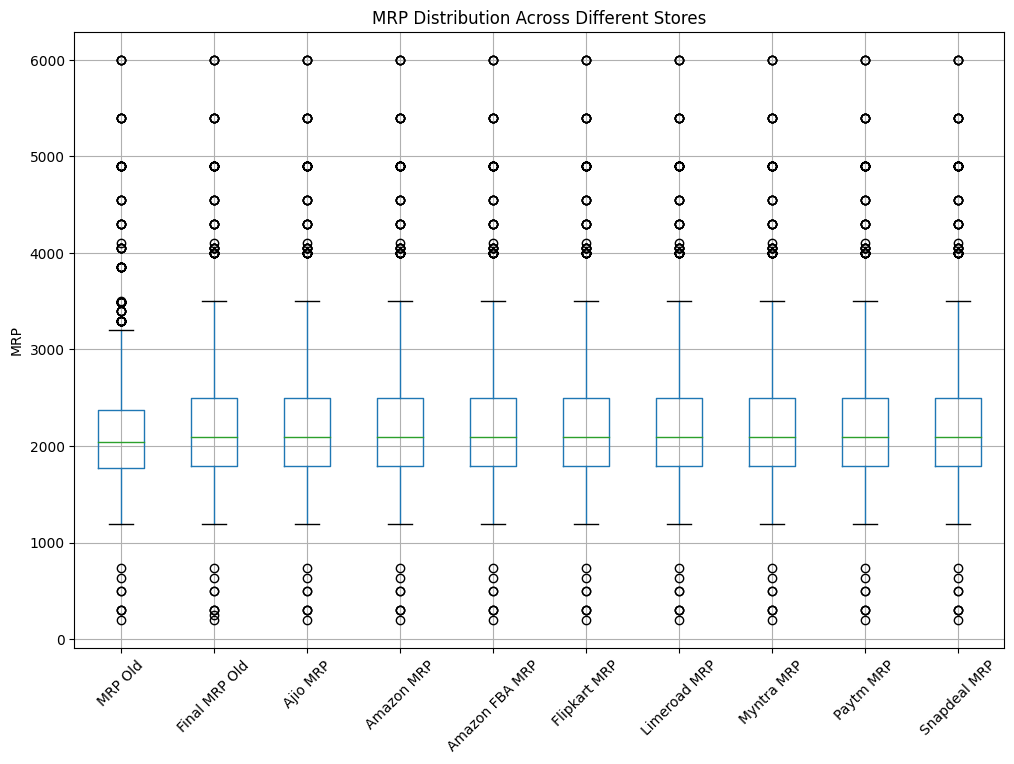

In [ ]:
import matplotlib.pyplot as plt

# DataFrame containing this columns
mrp_columns = ['MRP Old', 'Final MRP Old', 'Ajio MRP',
               'Amazon MRP', 'Amazon FBA MRP', 'Flipkart MRP', 'Limeroad MRP',
               'Myntra MRP', 'Paytm MRP', 'Snapdeal MRP']

# Converting MRP columns to numeric type
for col in mrp_columns:
    data['May-2022'][col] = pd.to_numeric(data['May-2022'][col], errors='coerce')

# Ploting MRP distribution across different stores
plt.figure(figsize=(12, 8))
data['May-2022'][mrp_columns].boxplot()
plt.title('MRP Distribution Across Different Stores')
plt.ylabel('MRP')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


Customer Behavior Analysis from Amazon Sale Report

<ipython-input-16-dcb638aa32e0>:8: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


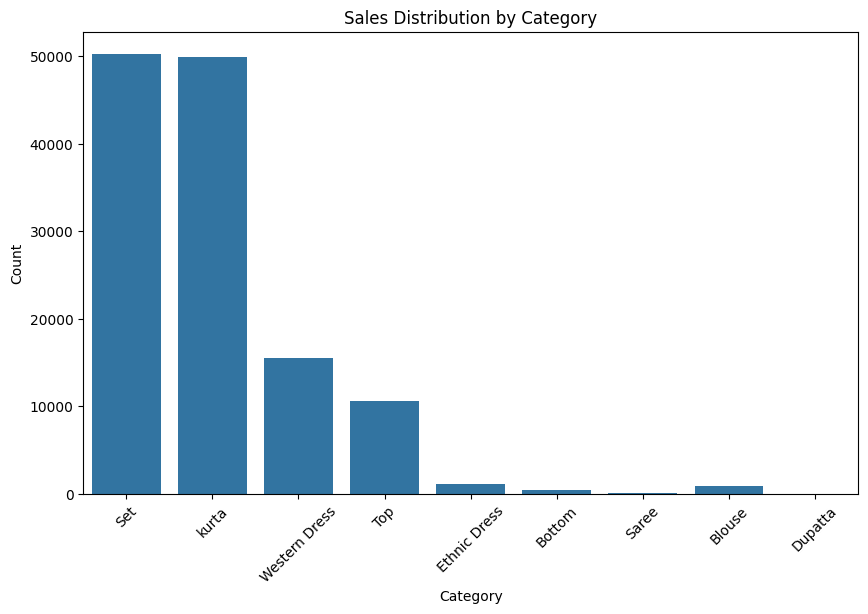

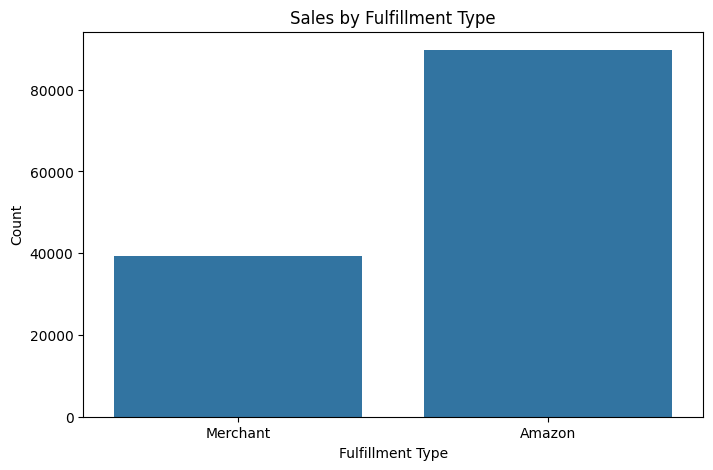

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Path
file_path = '/content/drive/My Drive/ecom/Amazon Sale Report.csv'
df = pd.read_csv(file_path)

# Sales distribution by category
plt.figure(figsize=(10, 6))
sns.countplot(x='Category', data=df)
plt.title('Sales Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Sales by fulfillment type
plt.figure(figsize=(8, 5))
sns.countplot(x='Fulfilment', data=df)
plt.title('Sales by Fulfillment Type')
plt.xlabel('Fulfillment Type')
plt.ylabel('Count')
plt.show()

**Feature Engineering**

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor

# Loading the Amazon Sale Report dataset
file_path = '/content/drive/My Drive/ecom/Amazon Sale Report.csv'
column_types = {'Order ID': str, 'Date': str, 'Status': str, 'Fulfilment': str, 'Sales Channel ': str,
                'ship-service-level': str, 'Style': str, 'SKU Code': str, 'Category': str, 'Size': str,
                'ASIN': str, 'Courier Status': str, 'Qty': float, 'currency': str, 'Amount': float,
                'ship-city': str, 'ship-state': str, 'ship-postal-code': str, 'ship-country': str,
                'promotion-ids': str, 'B2B': str, 'fulfilled-by': str, 'Unnamed: 22': str}

df = pd.read_csv(file_path, dtype=column_types)

# Handling missing values
df = df.dropna(subset=['Order ID', 'Date', 'Status', 'SKU Code', 'Qty', 'Amount'])

# Converting 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Create new datetime columns
df.loc[df['Date'].notnull(), 'Month'] = df.loc[df['Date'].notnull(), 'Date'].dt.month
df.loc[df['Date'].notnull(), 'Year'] = df.loc[df['Date'].notnull(), 'Date'].dt.year
df.loc[df['Date'].notnull(), 'Day_of_Week'] = df.loc[df['Date'].notnull(), 'Date'].dt.day_name()

# Feature engineering
df.loc[:, 'Date'] = pd.to_datetime(df['Date'])
df.loc[:, 'Month'] = df['Date'].dt.month
df.loc[:, 'Year'] = df['Date'].dt.year
df.loc[:, 'Day_of_Week'] = df['Date'].dt.day_name()
df.loc[:, 'Total_Order_Value'] = df['Qty'] * df['Amount']
df.loc[:, 'Category_Size'] = df['Category'] + '_' + df['Size']

# One-hot encoding for categorical variables
categorical_cols = ['Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Courier Status', 'ship-state', 'ship-country', 'B2B', 'fulfilled-by']
df = pd.get_dummies(df, columns=categorical_cols)

# Feature Selection
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

X = df.drop(['Order ID', 'Total_Order_Value'], axis=1)
y = df['Total_Order_Value']

# Encoding datetime columns
datetime_cols = ['Month', 'Year', 'Day_of_Week']
categorical_transformer = OneHotEncoder(handle_unknown='ignore')
preprocessor = ColumnTransformer(transformers=[('encoder', categorical_transformer, datetime_cols)])
X_encoded = preprocessor.fit_transform(X)

# Train-Test Split the data Set
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Training the Random Forest Regression model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Feature Importance Analysis
feature_importances = rf_model.feature_importances_
feature_names = X.columns

# Sorting features by importance
sorted_importances = sorted(zip(feature_names, feature_importances), key=lambda x: x[1], reverse=True)

# Printing the feature importances
print("Feature Importances:")
for name, importance in sorted_importances:
    print(f"{name}: {importance:.3f}")

Feature Importances:
Date: 0.798
Qty: 0.033
Size: 0.031
ship-city: 0.030
Amount: 0.022
currency: 0.022
ship-postal-code: 0.021
SKU Code: 0.015
ASIN: 0.012
Style: 0.011
index: 0.003
Category: 0.000


In [ ]:

df = pd.read_csv(file_path, dtype=column_types)

# Handling missing values
df = df.dropna(subset=['Order ID', 'Date', 'Status', 'SKU Code', 'Qty', 'Amount'])

# Converting 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Feature engineering
df.loc[:, 'Month'] = df['Date'].dt.month
df.loc[:, 'Year'] = df['Date'].dt.year
df.loc[:, 'Day_of_Week'] = df['Date'].dt.day_name()
df.loc[:, 'Total_Order_Value'] = df['Qty'] * df['Amount']
df.loc[:, 'Category_Size'] = df['Category'] + '_' + df['Size']

# Selecting relevant features
features = ['Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Courier Status',
            'ship-state', 'ship-country', 'B2B', 'fulfilled-by', 'Qty', 'Amount', 'Category_Size',
            'Month', 'Year', 'Day_of_Week']

X = df[features]
y = df['Total_Order_Value']

# One-hot encoding for categorical variables
X = pd.get_dummies(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the Random Forest Regression model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Feature Importance Analysis
feature_importances = rf_model.feature_importances_
sorted_indices = feature_importances.argsort()[::-1]

# Printing feature importances
print("Feature Importances:")
for idx in sorted_indices:
    print(f"{X.columns[idx]}: {feature_importances[idx]:.3f}")


Feature Importances:
Amount: 0.710
Qty: 0.282
ship-state_PUNJAB: 0.001
B2B_FALSE: 0.001
Status_Shipped - Delivered to Buyer: 0.001
Category_Size_Set_XS: 0.001
Day_of_Week_Tuesday: 0.001
B2B_TRUE: 0.001
Day_of_Week_Saturday: 0.001
Fulfilment_Amazon: 0.000
Status_Shipped: 0.000
Category_Size_Set_3XL: 0.000
ship-service-level_Standard: 0.000
ship-service-level_Expedited: 0.000
fulfilled-by_Easy Ship: 0.000
ship-state_UTTAR PRADESH: 0.000
Fulfilment_Merchant: 0.000
Month: 0.000
Category_Size_kurta_L: 0.000
ship-state_TAMIL NADU: 0.000
Category_Size_kurta_S: 0.000
Day_of_Week_Monday: 0.000
ship-state_KARNATAKA: 0.000
Day_of_Week_Sunday: 0.000
Category_Size_kurta_XXL: 0.000
Category_Size_kurta_XL: 0.000
Day_of_Week_Wednesday: 0.000
Category_Size_kurta_M: 0.000
Category_Size_Set_XL: 0.000
Category_Size_Western Dress_XS: 0.000
ship-state_HARYANA: 0.000
Category_Size_Western Dress_XXL: 0.000
Day_of_Week_Thursday: 0.000
Day_of_Week_Friday: 0.000
Status_Shipped - Returned to Seller: 0.000
Categor

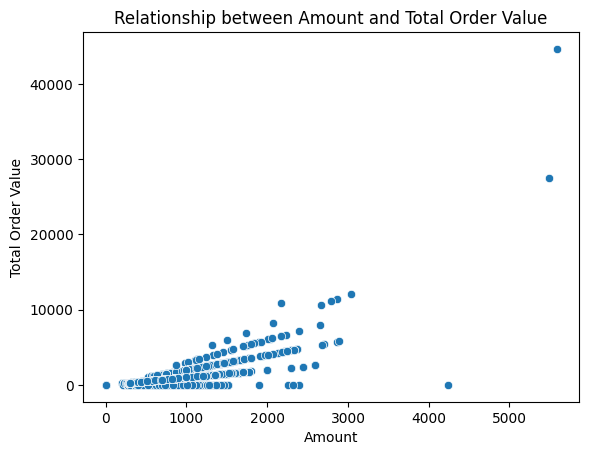

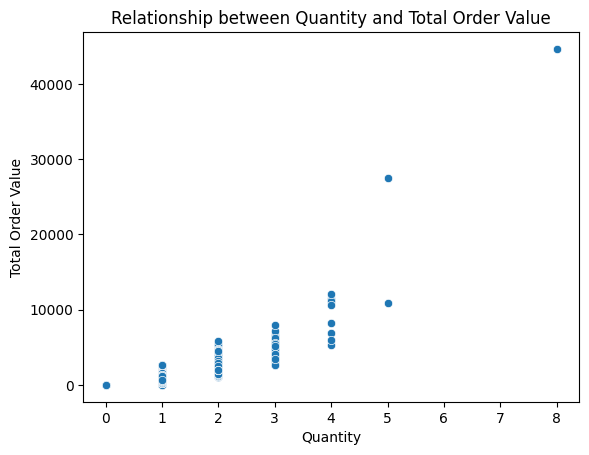

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Analyzing relationship between 'Amount' and 'Total_Order_Value'
sns.scatterplot(x='Amount', y='Total_Order_Value', data=df)
plt.title('Relationship between Amount and Total Order Value')
plt.xlabel('Amount')
plt.ylabel('Total Order Value')
plt.show()

# Analyzing relationship between 'Qty' and 'Total_Order_Value'
sns.scatterplot(x='Qty', y='Total_Order_Value', data=df)
plt.title('Relationship between Quantity and Total Order Value')
plt.xlabel('Quantity')
plt.ylabel('Total Order Value')
plt.show()


In [ ]:
correlation_matrix = df[['Amount', 'Qty', 'Total_Order_Value']].corr()
print(correlation_matrix)


                     Amount       Qty  Total_Order_Value
Amount             1.000000  0.066900           0.811896
Qty                0.066900  1.000000           0.496464
Total_Order_Value  0.811896  0.496464           1.000000


**Model Development**

In [ ]:
!pip install eli5


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for eli5: filename=eli5-0.13.0-py2.py3-none-any.whl size=107720 sha256=261e201ae3cc0ff484e53c3c481c0cec0c366c599a4f7cdc735990abf05ee940
  Stored in directory: /root/.cache/pip/wheels/b8/58/ef/2cf4c306898c2338d51540e0922c8e0d6028e07007085c0004
Successfully built eli5


In [ ]:
import eli5
from eli5.sklearn import PermutationImportance
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Random Forest Regression model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predicting on the test set
y_pred = rf_model.predict(X_test)

# Evaluating the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)


Mean Squared Error: 20.52803662320515
Mean Absolute Error: 0.09633767948506343


**Explainable AI (XAI) Integration**

In [ ]:
import eli5
from eli5.sklearn import PermutationImportance

# Calculating permutation importances
perm = PermutationImportance(rf_model).fit(X_test, y_test)

# Visualize feature importances
eli5.show_weights(perm, feature_names=X_test.columns.tolist())


Weight,Feature
1.4868 ± 0.0042,Amount
0.4519 ± 0.0154,Qty
0.0000 ± 0.0000,Category_Size_Set_3XL
0.0000 ± 0.0000,ship-state_UTTAR PRADESH
0.0000 ± 0.0000,ship-state_WEST BENGAL
0.0000 ± 0.0000,Month
0.0000 ± 0.0000,Category_Size_kurta_L
0.0000 ± 0.0000,Category_Size_kurta_M
0.0000 ± 0.0000,Fulfilment_Merchant
0.0000 ± 0.0000,ship-state_MAHARASHTRA
